In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-performance-in-exams/StudentsPerformance.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética básica
plt.style.use("default")
sns.set(style="whitegrid")


In [4]:
# Ajusta la ruta según cómo aparezca en Kaggle (input > dataset)
# Ejemplo típico:
data_path = "/kaggle/input/students-performance-in-exams/StudentsPerformance.csv"

df = pd.read_csv(data_path)

df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df = df.rename(columns={
    "gender": "genero",
    "race/ethnicity": "grupo_etnico",
    "parental level of education": "educacion_padres",
    "lunch": "almuerzo",
    "test preparation course": "curso_preparacion",
    "math score": "matematicas",
    "reading score": "lectura",
    "writing score": "escritura"
})

df.head()


,genero,grupo_etnico,educacion_padres,almuerzo,curso_preparacion,matematicas,lectura,escritura
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
df["promedio"] = df[["matematicas", "lectura", "escritura"]].mean(axis=1)
df[["matematicas", "lectura", "escritura", "promedio"]].head()


,matematicas,lectura,escritura,promedio
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


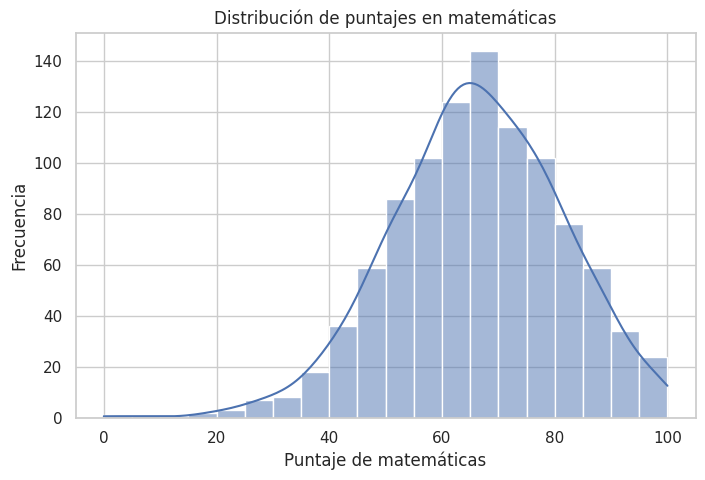

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["matematicas"], kde=True, bins=20)
plt.title("Distribución de puntajes en matemáticas")
plt.xlabel("Puntaje de matemáticas")
plt.ylabel("Frecuencia")
plt.show()


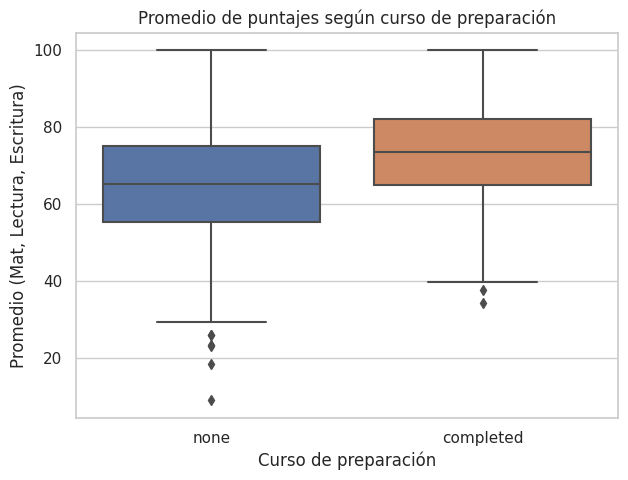

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="curso_preparacion", y="promedio")
plt.title("Promedio de puntajes según curso de preparación")
plt.xlabel("Curso de preparación")
plt.ylabel("Promedio (Mat, Lectura, Escritura)")
plt.show()


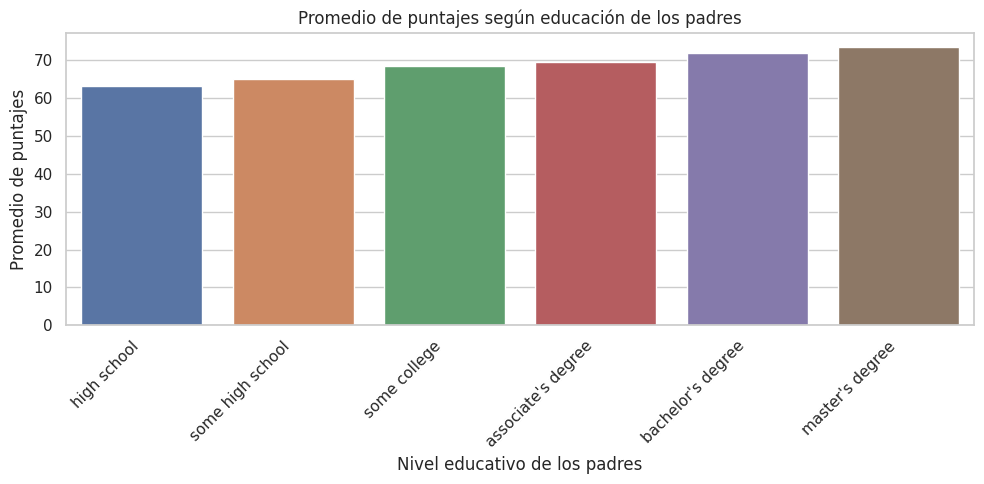

In [12]:
promedio_por_educacion = df.groupby("educacion_padres")["promedio"].mean().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=promedio_por_educacion.index, y=promedio_por_educacion.values)
plt.title("Promedio de puntajes según educación de los padres")
plt.xlabel("Nivel educativo de los padres")
plt.ylabel("Promedio de puntajes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
conclusiones = """
CONCLUSIONES DEL EDA (Students Performance in Exams)

1. Distribución de matemáticas:
   La mayoría de estudiantes se concentra alrededor de puntajes intermedios (entre 60 y 80),
   con menos estudiantes en los extremos muy bajos o muy altos. Esto indica que la cohorte
   tiene un rendimiento medio, con margen de mejora.

2. Curso de preparación:
   Al comparar el promedio de los estudiantes que hicieron el curso de preparación frente a los que no,
   se observa que el grupo que SÍ tomó el curso tiende a obtener un promedio ligeramente mayor.
   Esto sugiere que los cursos de refuerzo pueden tener un impacto positivo en el rendimiento académico.

3. Educación de los padres:
   Existe una ligera tendencia a que los estudiantes cuyos padres tienen un nivel educativo más alto
   presenten mejores promedios. Esto puede relacionarse con mayor apoyo académico en casa,
   mejor comprensión de la importancia del estudio y acceso a más recursos educativos.

RELACIÓN CON EDUCACIÓN:
Este análisis permite identificar factores asociados al rendimiento estudiantil (curso de preparación y educación de los padres).
Estos insights pueden usarse para:
- Priorizar apoyos adicionales a estudiantes sin curso de preparación.
- Diseñar intervenciones focalizadas en contextos con menor nivel educativo de los padres.
- Integrar modelos de IA que, usando estos datos, puedan predecir riesgo de bajo rendimiento
  y recomendar acciones personalizadas.
"""
print(conclusiones)
